# 프로젝트(알약 인식) Kaggle 원본 데이터 분석

4팀 김건 (2026/09/11)

---

## EDA
### 1. Kaggle Data Note 살펴보기
- 이미지는 PNG 형식, 주석은 COCO 포맷(JSON)으로 제공
- 각 알약의 위치(Bonding Box)와 클래스 정보가 포함
- 외부 데이터 사용은 가능하나 클래스 정보가 다를 수 있음 -> _"외부 대이터를 사용할 것인가?"_
- 평가용 데이터에는 학습용 데이터엔 없는 클래스가 존재 -> _"학습에 없던 클래스를 어떻게 해결할 것인가?"_
- 제공된 데이터에는 크고 작은 오류들이 포함 -> _"오류가 무엇이고, 어떻게 분류할 것인가?"_
- "bbox"의 값은 리스트 형태이며, 리스트의 길이가 정확히 4여야 합니다. 이는 [x, y, width, height] 형식을 의미하며, 이 조건을 만족해야 어노테이션에 ID가 부여 -> _"'bbox'가 4개가 아니면 제외해야 함"_
- 학습용 이미지, 학습용 상세내용, 평가용 이미지 등 3개의 폴더로 구성되어 있으며, 각각 232개, 114개, 842개의 파일과 폴더로 구성되어 있음 -> _"다운로드 후 확인 예정"_

### 2. 데이터 살펴보기 (육안 검토)
- 폴더 구조 : 학습용 이미지 데이터, 학습용 상세내용(annotation) 데이터, 평가용 이미지 데이터 각 1개 폴더 존재
- 이미지 파일 특징 : PNG 파일 형태. 세로 길이가 긴 형태. 파일마다 약 3~4개의 알약 위치. 보통 하늘색 배경이나 탈색된 것 같은 이미지 존재. 배경의 모양이 원형이라 파일 모서리 부분에 다른 배경이 존재하는 경우 있음
- 이미지 파일 갯수 : 학습용(232개), 테스트(842개)
- 상세내용 파일 특징 : JSON 파일 형태
- 상세내용 파일 갯수 : 파악 어려움(∵ 이미지 파일과 달리 폴더 내 폴더 구조. 이미지 1개당 여러 알약이 존재하기 때문이라고 추정). 코드로 파악 필요 

In [3]:
#@title 라이브러리 가져오기

import os
import torch
import numpy as np

### 3. 이미지와 JSON 파일의 갯수 및 매칭 파악
- 이미지와 JSON 파일 전체 수집 및 갯수 파악
- 매칭이 안되는 데이터 포함 여부 확인

In [4]:
from PIL import Image
from collections import defaultdict

# 경로 설정
train_img_dir = "../data/raw/sprint_ai_project1_data/train_images/"
train_annot_dir = "../data/raw/sprint_ai_project1_data/train_annotations/"

img_paths = {}
json_paths = defaultdict(list)

# 이미지 파일 수집
for root, dirs, files in os.walk(train_img_dir):
    for file in files:
        if file.endswith(".png"):
            name = os.path.splitext(file)[0]
            img_paths[name] = os.path.join(root, file)

# JSON 파일 수집 (같은 사진이 여러 폴더에 나뉘어 있으므로 append로 누적)
for root, dirs, files in os.walk(train_annot_dir):
    for file in files:
        if file.endswith(".json"):
            name = os.path.splitext(file)[0]
            json_paths[name].append(os.path.join(root, file))

img_names_set = set(img_paths.keys())
json_names_set = set(json_paths.keys())
missing_jsons = img_names_set - json_names_set
missing_imgs = json_names_set - img_names_set
valid_names = list(img_names_set & json_names_set)

print(f"학습용 이미지 갯수: {len(img_paths)}개")
print(f"학습용 json 파일 실물 갯수: {sum(len(v) for v in json_paths.values())}개")
print(f"상세내용이 없는 이미지 갯수: {len(missing_jsons)}개")
print(f"이미지가 없는 상세내용 갯수: {len(missing_imgs)}개")
print(f"매칭 데이터(사진 단위) 갯수: {len(valid_names)}개")

학습용 이미지 갯수: 232개
학습용 json 파일 실물 갯수: 763개
상세내용이 없는 이미지 갯수: 0개
이미지가 없는 상세내용 갯수: 0개
매칭 데이터(사진 단위) 갯수: 232개


### 4. 이미지 크기 확인
- 이미지 데이터별 크기 차이 여부 확인

📏 [이미지 해상도 및 비율 분석 결과]
가로(Width) 평균: 976px (최소 976 ~ 최대 976)
세로(Height) 평균: 1280px (최소 1280 ~ 최대 1280)
가로/세로 비율 평균: 0.76 (1.0 기준)


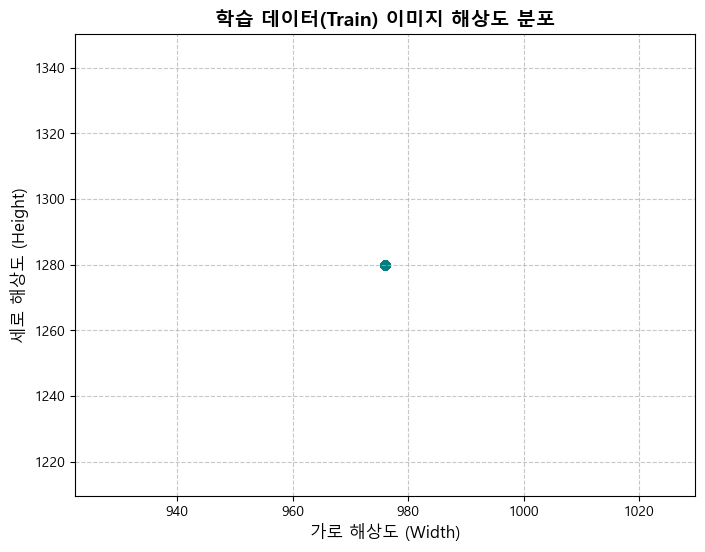

In [5]:
import json
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False       # 마이너스 기호 깨짐 방지

widths = []
heights = []
ratios = []

for name in valid_names:
    # 같은 사진의 형제 json들은 이미지 크기가 동일 → 대표로 1개만 열어봄
    with open(json_paths[name][0], 'r', encoding='utf-8') as f:
        data = json.load(f)
    w = data['images'][0]['width']
    h = data['images'][0]['height']
    widths.append(w); heights.append(h); ratios.append(w / h)

print("📏 [이미지 해상도 및 비율 분석 결과]")
print(f"가로(Width) 평균: {int(sum(widths)/len(widths))}px (최소 {min(widths)} ~ 최대 {max(widths)})")
print(f"세로(Height) 평균: {int(sum(heights)/len(heights))}px (최소 {min(heights)} ~ 최대 {max(heights)})")
print(f"가로/세로 비율 평균: {sum(ratios)/len(ratios):.2f} (1.0 기준)")

plt.figure(figsize=(8, 6))
plt.scatter(widths, heights, alpha=0.5, color='teal')
plt.title('학습 데이터(Train) 이미지 해상도 분포', fontsize=14, fontweight='bold')
plt.xlabel('가로 해상도 (Width)', fontsize=12)
plt.ylabel('세로 해상도 (Height)', fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.show()

### 5. Data 본래의 한계로 인한 오류 발생 방지
- bbox가 4개인 파일만 유효함으로 해당하지 않는 data 제거를 위한 확인
- bbox가 외부로 노출되어 오류를 일으킬 수 있는 데이터 제거를 위한 확인
- 알약 이미지가 너무 작아(기준 : 전체 면적의 1% 미만) 학습이 어려울 수 있는 경우 확인
- bbox의 좌표와 사진의 실제 위치가 적합한지 확인
- 클래스 갯수 및 클래스별 빈도를 확인하여 데이터 불균형이 있는지 확인

In [6]:
# 잘못된 bbox 검출을 통한 오류 발생 여지 제거

# 각 확인사항 초기화
defective_bboxes = 0
out_of_bounds_count = 0
small_object_count = 0
total_annotations_checked = 0
pill_class_counts = {}
pills_per_image = []  
bad_records = []

for name in valid_names:
    annos_this_image = 0

    for json_path in json_paths[name]:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        img_w = data['images'][0]['width']
        img_h = data['images'][0]['height']
        img_area = img_w * img_h

        pill_name = data['images'][0]['dl_name']
        pill_class_counts[pill_name] = pill_class_counts.get(pill_name, 0) + 1

        for anno in data['annotations']:
            total_annotations_checked += 1
            annos_this_image += 1

            if 'bbox' not in anno or not isinstance(anno['bbox'], list) or len(anno['bbox']) != 4:
                defective_bboxes += 1
                continue

            x, y, w, h = anno['bbox']
            if x < 0 or y < 0 or (x + w) > img_w or (y + h) > img_h:
                out_of_bounds_count += 1
                bad_records.append({           # ← 추가
                    'name': name,
                    'json_path': json_path,
                    'annotation_id': anno.get('id'),
                    'bbox': anno['bbox'],
                    'image_size': (img_w, img_h)
                })

                pills_per_image.append(annos_this_image)

print(f"총 검사한 알약 객체 수: {total_annotations_checked}건")
print(f"bbox가 4개가 아닌 데이터 수: {defective_bboxes}건")
print(f"화면 밖으로 이탈한 좌표 갯수: {out_of_bounds_count}건")
print(f"너무 작은 알약 이미지 갯수: {small_object_count}건")
print(f"확인된 알약 클래스 수: {len(pill_class_counts)}종")
print(f"사진 1장당 알약 개수 - 최소 {min(pills_per_image)}개 / 최대 {max(pills_per_image)}개 / 평균 {np.mean(pills_per_image):.1f}개")
print(f"격리 대상(bad_records): {len(bad_records)}건")

총 검사한 알약 객체 수: 763건
bbox가 4개가 아닌 데이터 수: 0건
화면 밖으로 이탈한 좌표 갯수: 1건
너무 작은 알약 이미지 갯수: 0건
확인된 알약 클래스 수: 56종
사진 1장당 알약 개수 - 최소 3개 / 최대 3개 / 평균 3.0개
격리 대상(bad_records): 1건


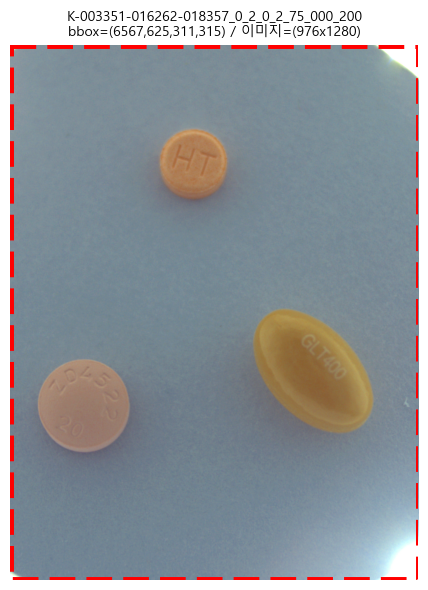

In [7]:
# 화면 밖ㅇ로 이탈한 파일 확인

import matplotlib.patches as patches

n = len(bad_records)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
if n == 1:
    axes = [axes]   # 1개일 때도 반복문이 돌아가도록 리스트로 맞춰줌

for ax, r in zip(axes, bad_records):
    name = r['name']
    img_w, img_h = r['image_size']

    img = Image.open(img_paths[name])
    ax.imshow(img)

    # 문제의 bbox (빨간색)
    x, y, w, h = r['bbox']
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    # 이미지 경계선 (초록 점선) - bbox가 어디까지 벗어났는지 비교하기 위함
    border = patches.Rectangle((0, 0), img_w, img_h, linewidth=5, edgecolor='red', facecolor='none', linestyle='--')
    ax.add_patch(border)

    ax.set_title(f"{name}\nbbox=({x},{y},{w},{h}) / 이미지=({img_w}x{img_h})", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

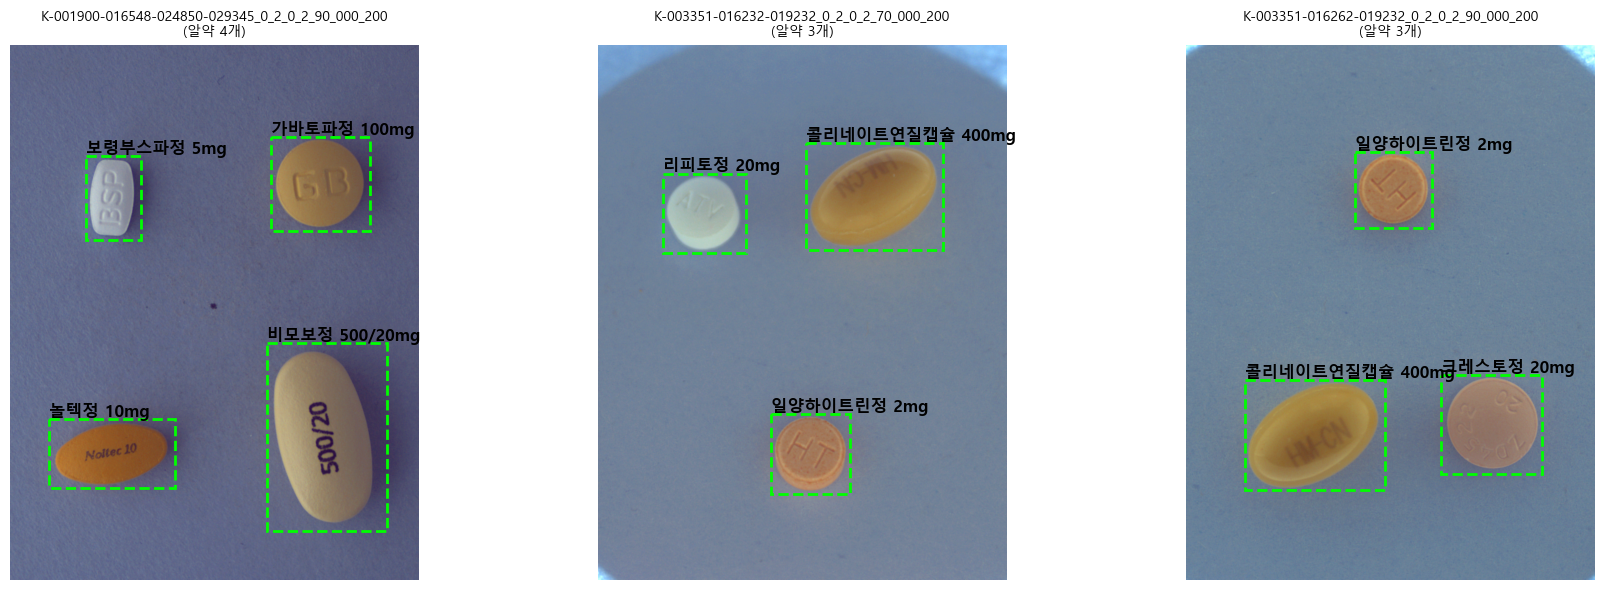

In [8]:
#

import random
import matplotlib.patches as patches

random.seed(42)
sample_names = random.sample(valid_names, 3)  # 무작위로 3장만 확인

fig, axes = plt.subplots(1, len(sample_names), figsize=(6 * len(sample_names), 6))

for ax, name in zip(axes, sample_names):
    img = Image.open(img_paths[name])
    ax.imshow(img)

    # 알약의 갯수만큼 박스 삽입
    for json_path in json_paths[name]:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        pill_name = data['images'][0]['dl_name']

        for anno in data['annotations']:
            if 'bbox' not in anno or len(anno['bbox']) != 4:
                continue
            x, y, w, h = anno['bbox']
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='lime', facecolor='none', linestyle='--')
            ax.add_patch(rect)
            ax.text(x, y - 5, pill_name, color='k', fontsize=12, fontweight='bold')

    ax.set_title(f"{name}\n(알약 {sum(len(json.load(open(p, encoding='utf-8'))['annotations']) for p in json_paths[name])}개)", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
# 클래스(알약 종류)별 갯수 확인

print(f"클래스(알약 종류) 수: {len(pill_class_counts)}개\n")
for name, count in sorted(pill_class_counts.items(), key=lambda x: x[1], reverse=True):
    print(f" - {name}: {count}장")

클래스(알약 종류) 수: 56개

 - 일양하이트린정 2mg: 153장
 - 기넥신에프정(은행엽엑스)(수출용): 45장
 - 아토젯정 10/40mg: 37장
 - 크레스토정 20mg: 23장
 - 아토르바정 10mg: 22장
 - 리피토정 20mg: 21장
 - 플라빅스정 75mg: 20장
 - 뉴로메드정(옥시라세탐): 20장
 - 로수젯정10/5밀리그램: 19장
 - 로수바미브정 10/20mg: 18장
 - 리바로정 4mg: 18장
 - 가바토파정 100mg: 18장
 - 콜리네이트연질캡슐 400mg: 17장
 - 카발린캡슐 25mg: 16장
 - 마도파정: 16장
 - 글리틴정(콜린알포세레이트): 16장
 - 리피로우정 20mg: 16장
 - 에빅사정(메만틴염산염)(비매품): 15장
 - 보령부스파정 5mg: 15장
 - 리리카캡슐 150mg: 15장
 - 글리아타민연질캡슐: 14장
 - 종근당글리아티린연질캡슐(콜린알포세레이트) : 13장
 - 아질렉트정(라사길린메실산염): 12장
 - 아모잘탄정 5/100mg: 12장
 - 트윈스타정 40/5mg: 12장
 - 엑스포지정 5/160mg: 12장
 - 자누메트정 50/850mg: 12장
 - 트라젠타듀오정 2.5/850mg: 9장
 - 트라젠타정(리나글립틴): 9장
 - 뮤테란캡슐 100mg: 9장
 - 자누비아정 50mg: 9장
 - 오마코연질캡슐(오메가-3-산에틸에스테르90): 8장
 - 다보타민큐정 10mg/병: 6장
 - 큐시드정 31.5mg/PTP: 6장
 - 노바스크정 5mg: 6장
 - 스토가정 10mg: 6장
 - 비모보정 500/20mg: 6장
 - 무코스타정(레바미피드)(비매품): 6장
 - 에어탈정(아세클로페낙): 5장
 - 알드린정: 3장
 - 써스펜8시간이알서방정 650mg: 3장
 - 라비에트정 20mg: 3장
 - 울트라셋이알서방정: 3장
 - 리렉스펜정 300mg/PTP: 3장
 - 레일라정: 3장
 - 동아가바펜틴정 800mg: 3장
 - 에스원엠프정 20mg: 3장
 - 카나

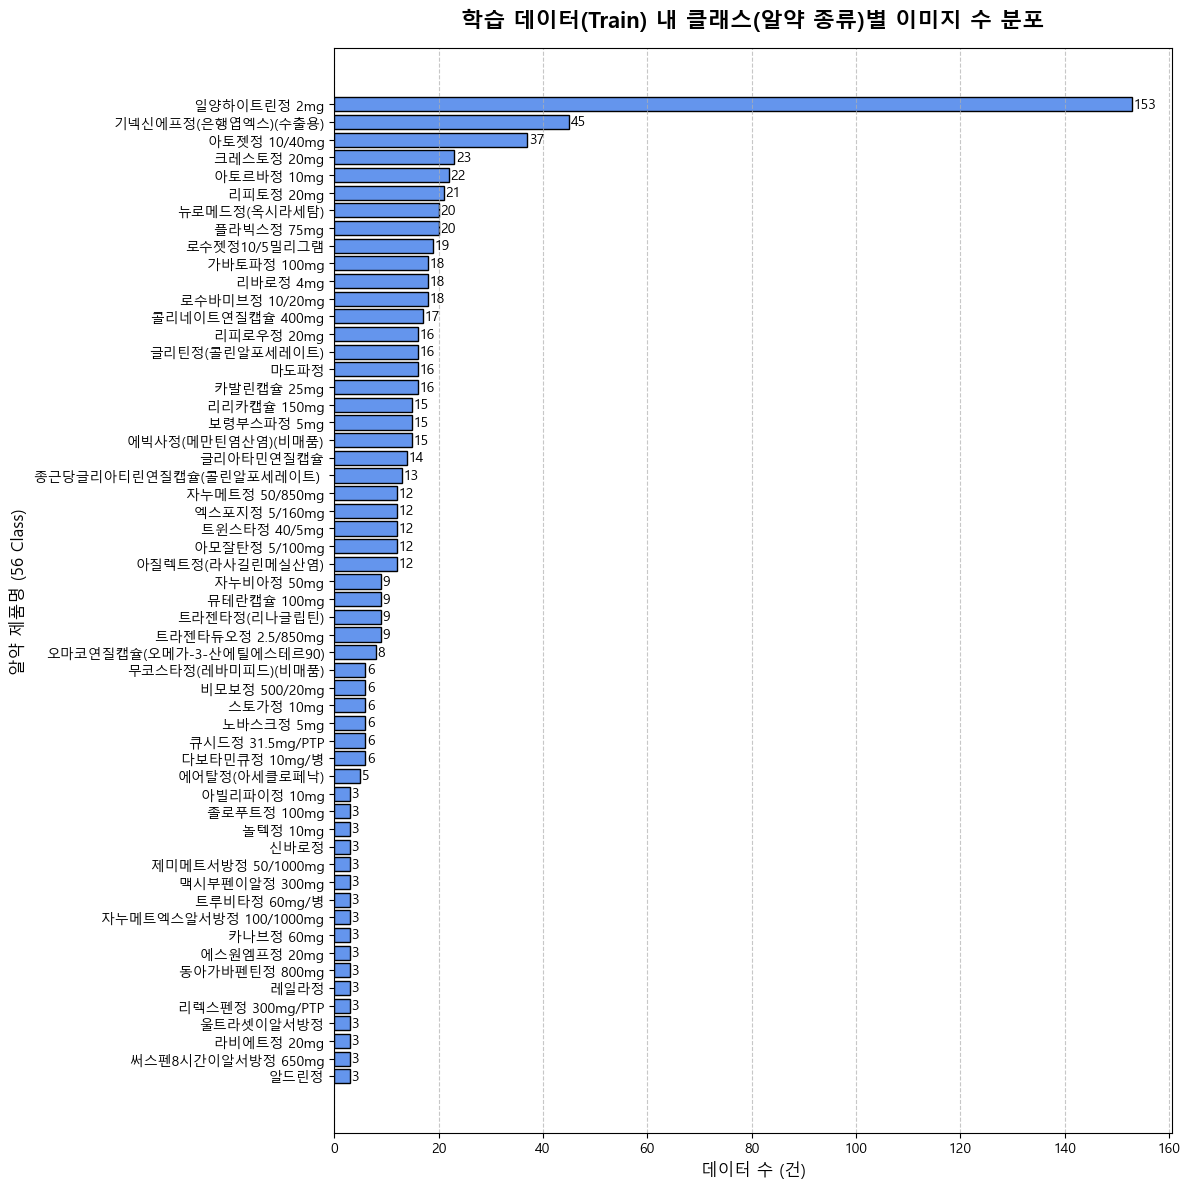

In [10]:
# 클래스 정렬 시각화

import matplotlib.font_manager as fm
import platform

# 내림차순 정렬
sorted_pills = sorted(pill_class_counts.items(), key=lambda x: x[1], reverse=False)
pill_names = [item[0] for item in sorted_pills]
pill_counts = [item[1] for item in sorted_pills]

# 시각화
plt.figure(figsize=(12, 12))
plt.barh(pill_names, pill_counts, color='cornflowerblue', edgecolor='black')

plt.title('학습 데이터(Train) 내 클래스(알약 종류)별 이미지 수 분포', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('데이터 수 (건)', fontsize=12)
plt.ylabel('알약 제품명 (56 Class)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(pill_counts):
    plt.text(value + 0.3, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 6. EDA 결과
- 데이터 연결 상태 : 이미지 1장에 알약이 여러 개(최소 2개 ~ 최대 4개, 평균 3.3개) 함께 촬영되어 있어, 알약별로 JSON 파일이 각각 나뉘어 저장되어 있음.
- 이미지 데이터 검증 : 전체 이미지 해상도가 976×1280으로 고정되어 있어 크기 편차 없음. 육안 검사 시 탈색·색조 차이가 있는 이미지 존재
- bbox 유효성 검증 : 763건 중 bbox 형식 오류 0건, 경계 이탈 1건, 과소 크기(면적 1% 미만) 0건으로 문제 데이터 비율은 매우 낮음
- bbox-이미지 일치 검증 : 샘플 3장에 bbox를 실제 이미지 위에 그려 확인한 결과, 알약 개수만큼 박스가 정확히 대응됨을 확인
- 클래스 분포 : 총 56개 클래스 존재, 최다 153건(일양하이트린정 2mg) ~ 최소 3건으로 불균형이 심함 → 데이터 증강으로 보완 예정
- 데이터 정제 필요 사항 : 일부 클래스명에 표기 차이(공백 등)가 있어(예: "종근당글리아티린연질캡슐(콜린알포세레이트) ") 전처리 단계에서 정규화 필요
- 남은 한계 : 평가용 데이터 중 학습용 데이터에 없는 클래스가 존재한다는 Data Note 내용은 테스트 라벨이 비공개라 이번 EDA에서 직접 검증하지 못함 → 추후 제출/피드백 결과로 간접 확인 예정